# LOAN DEFAULT RISK CLASSIFICATION FOR BANKING
## Stages 5–8: Feature Engineering → Model Building → Evaluation → Explainability

**Dataset:** Home Credit Default Risk (application_train.csv)  
**Target:** `TARGET` → 0 = No Default, 1 = Default  

> This notebook continues from Stage 4 (EDA). Run your EDA notebook first, or load the cleaned CSV produced there.

---
## IMPORT LIBRARIES

In [ ]:
# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# ── Feature Selection ─────────────────────────────────────────────────────────
from sklearn.feature_selection import SelectFromModel, mutual_info_classif

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# ── Imbalance ─────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, f1_score, recall_score
)

# ── Explainability ────────────────────────────────────────────────────────────
import shap

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 120
print('All libraries loaded successfully ✓')

All libraries loaded successfully ✓


---
## LOAD DATA (continuation from EDA notebook)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving application_train.csv to application_train.csv


In [ ]:
import pandas as pd
df = pd.read_csv("application_train.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target distribution:\n{df['TARGET'].value_counts()}")

Dataset loaded: 307,511 rows × 122 columns
Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [ ]:
# ── Repeat minimal preprocessing from Stage 3 ────────────────────────────────
# (So this notebook is self-contained and reproducible)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

Missing values after imputation: 0


---
# STAGE 5 : FEATURE ENGINEERING & SELECTION

Good features often matter more than the choice of model.  
We will:
1. Engineer domain-specific financial ratios
2. Encode categorical features
3. Remove low-variance and highly-correlated features
4. Rank remaining features by mutual information

### 5.1 — Domain-Specific Feature Engineering

In [ ]:
# ── 1. Credit-to-Income Ratio (debt burden) ───────────────────────────────────
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

# ── 2. Annuity-to-Income Ratio (monthly repayment burden) ────────────────────
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

# ── 3. Goods Price to Credit Ratio (LTV proxy) ───────────────────────────────
df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)

# ── 4. Credit Term in Years ───────────────────────────────────────────────────
df['CREDIT_TERM'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)

# ── 5. Age in Years (DAYS_BIRTH is negative in the dataset) ──────────────────
df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365

# ── 6. Years Employed (DAYS_EMPLOYED is negative for employed) ───────────────
#    Values > 0 indicate unemployed/pensioner — cap to 0
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].clip(upper=0)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED']) / 365

# ── 7. Employment-to-Age Ratio (stability indicator) ─────────────────────────
df['EMPLOYED_TO_AGE_RATIO'] = df['YEARS_EMPLOYED'] / (df['AGE_YEARS'] + 1)

# ── 8. Income per Family Member ───────────────────────────────────────────────
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

new_features = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'GOODS_CREDIT_RATIO',
    'CREDIT_TERM', 'AGE_YEARS', 'YEARS_EMPLOYED',
    'EMPLOYED_TO_AGE_RATIO', 'INCOME_PER_PERSON'
]
print("New engineered features:")
print(df[new_features].describe().T[['mean', 'std', 'min', 'max']].round(2))

New engineered features:
                           mean       std      min          max
CREDIT_INCOME_RATIO        3.96      2.69     0.00        84.73
ANNUITY_INCOME_RATIO       0.18      0.09     0.00         1.88
GOODS_CREDIT_RATIO         0.90      0.10     0.17         6.67
CREDIT_TERM               21.61      7.82     6.32        59.56
AGE_YEARS                 43.94     11.96    20.52        69.12
YEARS_EMPLOYED             5.36      6.32     0.00        49.07
EMPLOYED_TO_AGE_RATIO      0.13      0.13     0.00         0.72
INCOME_PER_PERSON      57482.59  65851.66  2647.06  29250000.00


### 5.2 — Encode Categorical Features

In [ ]:
# ── Label Encode all remaining object columns ─────────────────────────────────
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 16 categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


### 5.3 — Remove Highly Correlated Features

In [ ]:
# ── Drop features with correlation > 0.90 (keep one from each pair) ───────────
corr_matrix = df.drop(columns=['SK_ID_CURR', 'TARGET']).corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]

print(f"Dropping {len(to_drop)} highly correlated features: {to_drop[:10]} ...")
df.drop(columns=to_drop, inplace=True)
print(f"Remaining features: {df.shape[1] - 2}")

Dropping 36 highly correlated features: ['AMT_GOODS_PRICE', 'REGION_RATING_CLIENT_W_CITY', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE'] ...
Remaining features: 92


### 5.4 — Mutual Information Feature Ranking

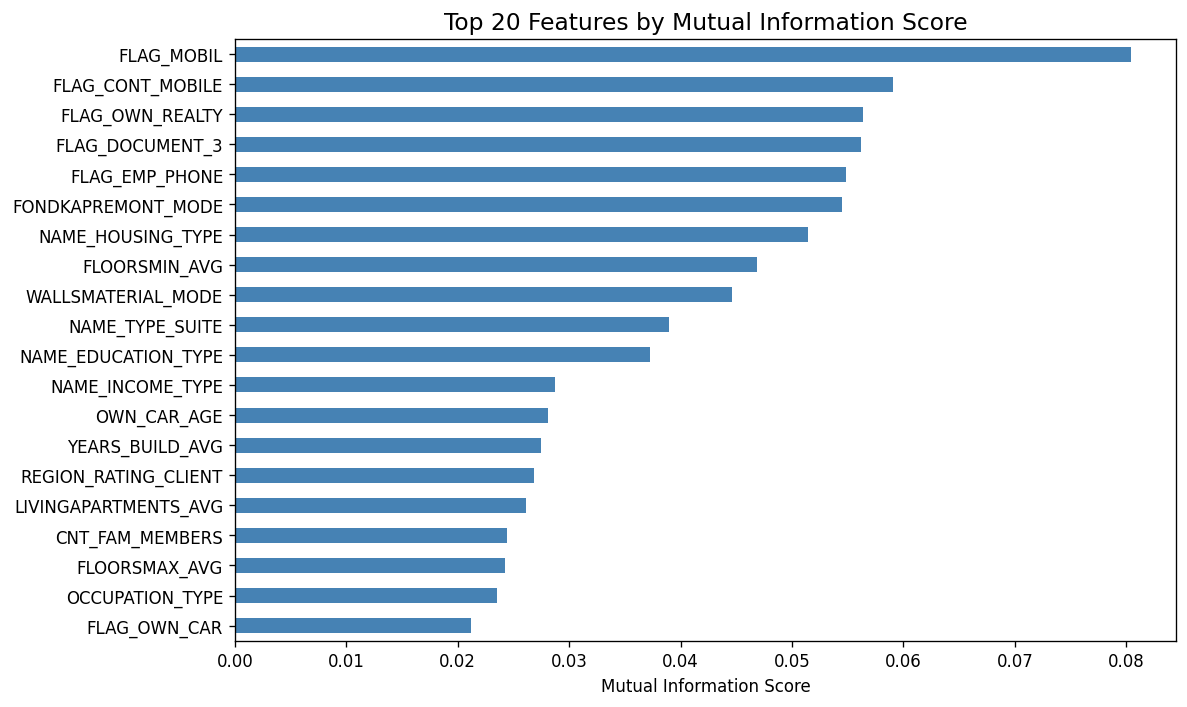

Top 20 features:
FLAG_MOBIL              0.0804
FLAG_CONT_MOBILE        0.0591
FLAG_OWN_REALTY         0.0563
FLAG_DOCUMENT_3         0.0562
FLAG_EMP_PHONE          0.0548
FONDKAPREMONT_MODE      0.0545
NAME_HOUSING_TYPE       0.0514
FLOORSMIN_AVG           0.0469
WALLSMATERIAL_MODE      0.0446
NAME_TYPE_SUITE         0.0390
NAME_EDUCATION_TYPE     0.0373
NAME_INCOME_TYPE        0.0287
OWN_CAR_AGE             0.0281
YEARS_BUILD_AVG         0.0275
REGION_RATING_CLIENT    0.0269
LIVINGAPARTMENTS_AVG    0.0262
CNT_FAM_MEMBERS         0.0244
FLOORSMAX_AVG           0.0243
OCCUPATION_TYPE         0.0235
FLAG_OWN_CAR            0.0212
dtype: float64


In [ ]:
# ── Prepare X and y ────────────────────────────────────────────────────────────
X_all = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y     = df['TARGET']

# ── Compute MI scores ─────────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X_all, y, random_state=42)
mi_df     = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

# ── Plot Top 20 ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
mi_df.head(20).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Mutual Information Score', fontsize=14)
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print("Top 20 features:")
print(mi_df.head(20).round(4))

In [ ]:
# ── Keep Top 50 features by MI score for modelling ───────────────────────────
TOP_N    = 50
top_feats = mi_df.head(TOP_N).index.tolist()

X = X_all[top_feats].copy()
print(f"Final feature matrix: {X.shape}")
print(f"Class balance:\n{y.value_counts(normalize=True).round(3)}")

Final feature matrix: (307511, 50)
Class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64





---
# STAGE 6 : MODEL BUILDING & TRAINING

We train three models as required by the project spec:
1. **Logistic Regression** (class-weighted baseline)
2. **Random Forest** (tree ensemble, class-weighted)
3. **LightGBM** (gradient boosted trees — best for tabular data)

We optimise for **Recall** on class 1 (default) to minimise risky approvals — a false negative (approving a defaulter) is costlier than a false positive.

### 6.1 — Train/Test Split + SMOTE

In [ ]:
# ── 80/20 stratified split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts()}")

# ── Apply SMOTE to training set only ─────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE train size : {X_train_sm.shape}")
print(f"After SMOTE class balance:\n{pd.Series(y_train_sm).value_counts()}")

Train size : (246008, 50)
Test  size : (61503, 50)
Train class balance:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE train size : (452296, 50)
After SMOTE class balance:
TARGET
0    226148
1    226148
Name: count, dtype: int64


### 6.2 — Feature Scaling (for Logistic Regression)

In [ ]:

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("Scaling done ✓")

Scaling done ✓


### 6.3 — Model 1: Logistic Regression

In [ ]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.1,
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train_sc, y_train_sm)
y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]

print("Logistic Regression trained ✓")
print(classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default']))

Logistic Regression trained ✓
              precision    recall  f1-score   support

  No Default       0.93      0.79      0.86     56538
     Default       0.14      0.37      0.20      4965

    accuracy                           0.76     61503
   macro avg       0.54      0.58      0.53     61503
weighted avg       0.87      0.76      0.80     61503



### 6.4 — Model 2: Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained ✓")
print(classification_report(y_test, y_pred_rf, target_names=['No Default', 'Default']))

Random Forest trained ✓
              precision    recall  f1-score   support

  No Default       0.93      0.92      0.92     56538
     Default       0.15      0.15      0.15      4965

    accuracy                           0.86     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.86      0.86     61503



### 6.5 — Model 3: LightGBM

In [ ]:
# ── Compute scale_pos_weight to handle class imbalance natively ───────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}")

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=50,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

y_pred_lgbm  = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("\nLightGBM trained ✓")
print(classification_report(y_test, y_pred_lgbm, target_names=['No Default', 'Default']))

scale_pos_weight = 11.39
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5337
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

LightGBM trained ✓
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



---
# STAGE 7 : MODEL EVALUATION & COMPARISON

We compare all three models across:
- Confusion Matrices
- ROC-AUC curves
- Precision-Recall curves
- Summary metrics table

### 7.1 — Confusion Matrices

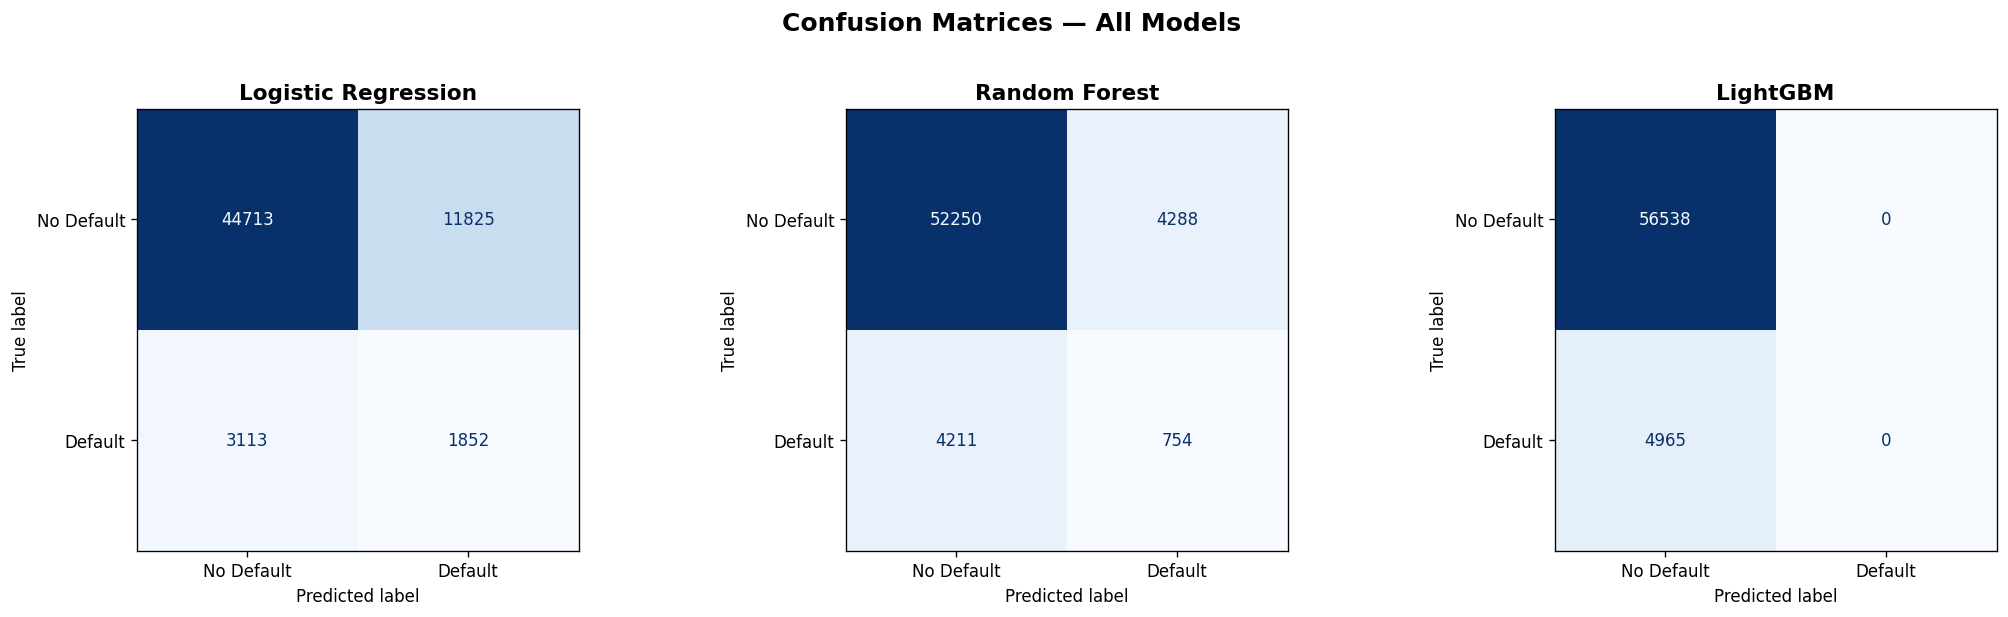

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',        y_pred_rf),
    ('LightGBM',             y_pred_lgbm)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 — ROC-AUC Curves

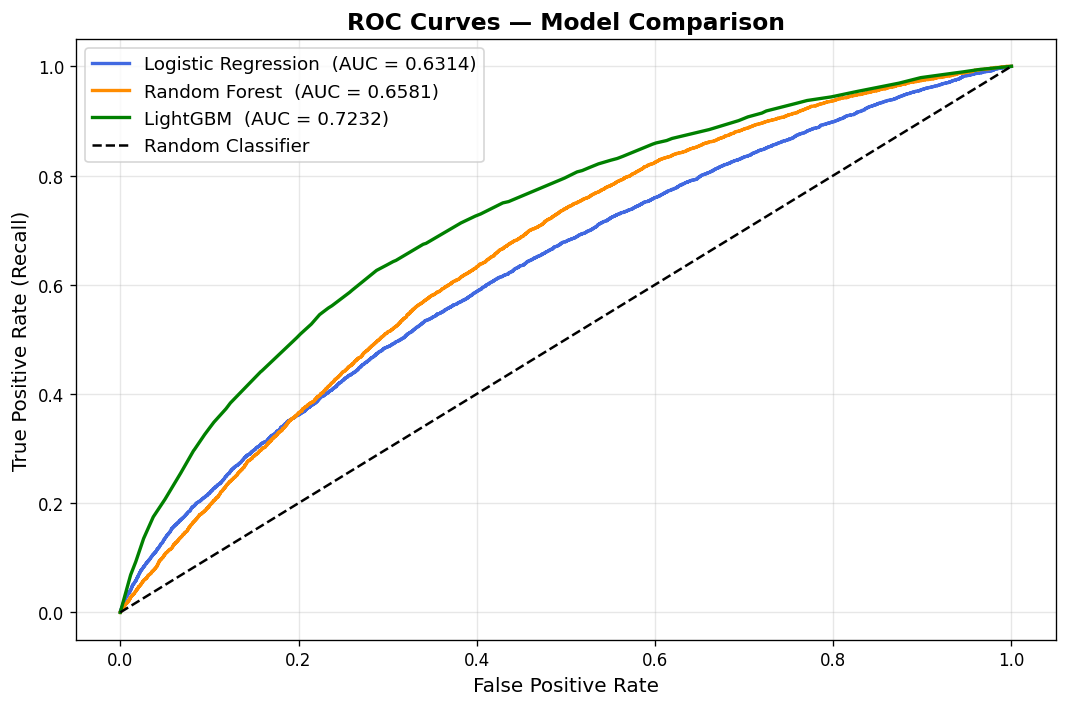

In [ ]:
plt.figure(figsize=(9, 6))

proba_dict = {
    'Logistic Regression': y_proba_lr,
    'Random Forest':        y_proba_rf,
    'LightGBM':             y_proba_lgbm
}
colors = ['royalblue', 'darkorange', 'green']

for (name, proba), color in zip(proba_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 — Precision-Recall Curves

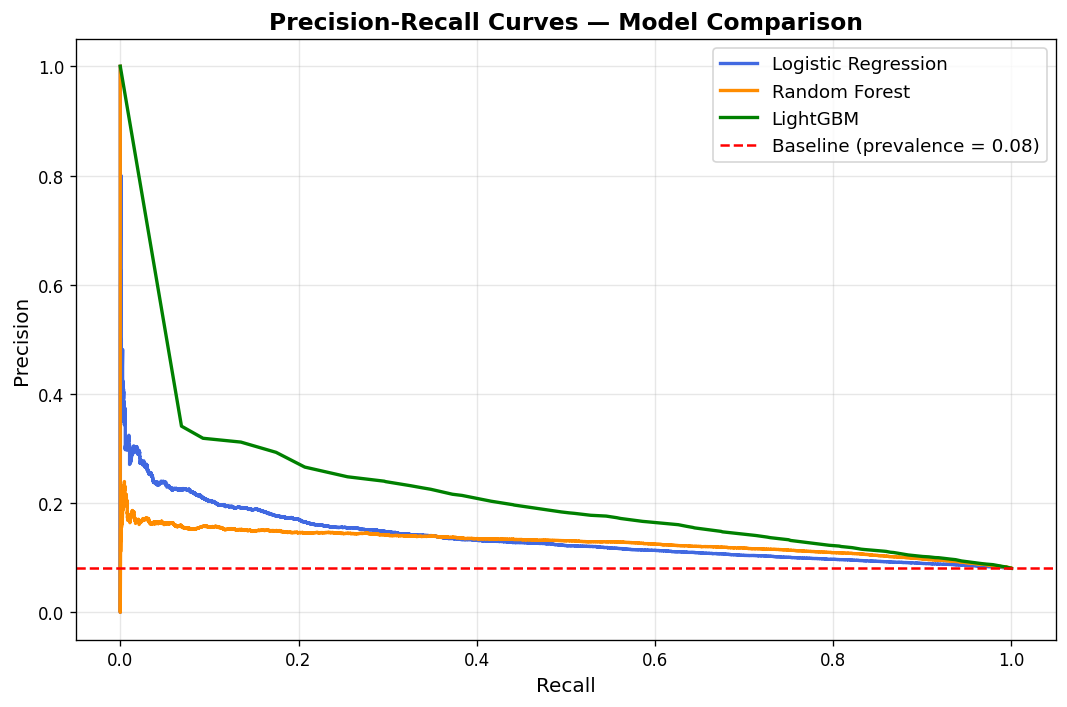

In [ ]:
plt.figure(figsize=(9, 6))

for (name, proba), color in zip(proba_dict.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name, color=color, lw=2)

baseline = y_test.mean()
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (prevalence = {baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 — Summary Metrics Table

In [ ]:
from sklearn.metrics import accuracy_score, precision_score

results = []
for name, y_pred, y_proba in [
    ('Logistic Regression', y_pred_lr,   y_proba_lr),
    ('Random Forest',        y_pred_rf,   y_proba_rf),
    ('LightGBM',             y_pred_lgbm, y_proba_lgbm)
]:
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test,  y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred),  4),
        'Recall':    round(recall_score(y_test,    y_pred),   4),
        'F1-Score':  round(f1_score(y_test,        y_pred),   4),
        'ROC-AUC':   round(roc_auc_score(y_test,   y_proba),  4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('\n===== Model Comparison Table =====')
print(results_df.to_string())

# ── Highlight best recall ─────────────────────────────────────────────────────
best_recall_model = results_df['Recall'].idxmax()
best_auc_model    = results_df['ROC-AUC'].idxmax()
print(f"\n→ Best Recall  : {best_recall_model}")
print(f"→ Best ROC-AUC : {best_auc_model}")


===== Model Comparison Table =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7571     0.1354  0.3730    0.1987   0.6314
Random Forest          0.8618     0.1495  0.1519    0.1507   0.6581
LightGBM               0.9193     0.0000  0.0000    0.0000   0.7232

→ Best Recall  : Logistic Regression
→ Best ROC-AUC : LightGBM


### 7.5 — Cross-Validation (LightGBM — Best Model)

LightGBM 5-Fold CV ROC-AUC Scores: [0.7551 0.7649 0.7566 0.7624 0.7537]
Mean  : 0.7585
Std   : 0.0043


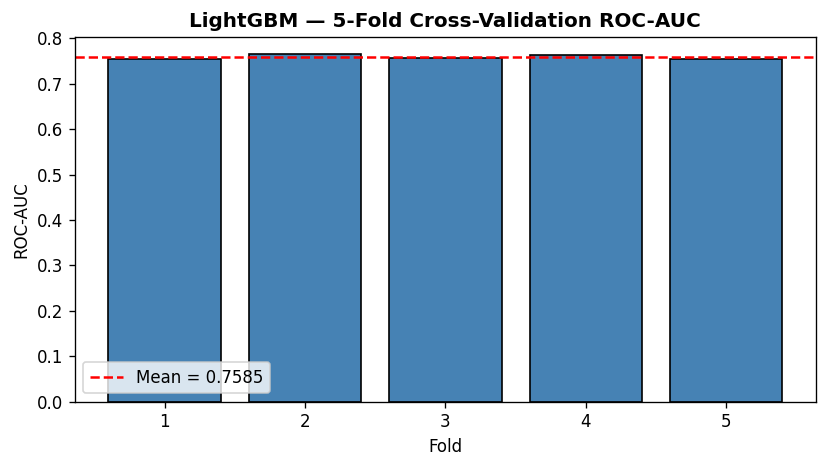

In [ ]:
# ── 5-Fold Stratified CV on LightGBM ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgbm, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"LightGBM 5-Fold CV ROC-AUC Scores: {cv_scores.round(4)}")
print(f"Mean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.title('LightGBM — 5-Fold Cross-Validation ROC-AUC', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 7.6 — Threshold Tuning for Recall Optimisation

In [ ]:
# ── Find threshold that maximises Recall with acceptable Precision ─────────────
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_lgbm)

# Target: recall >= 0.70, then pick highest precision
candidates = pd.DataFrame({
    'Threshold': thresholds_arr,
    'Precision': precision_arr[:-1],
    'Recall':    recall_arr[:-1]
})

good_thresholds = candidates[candidates['Recall'] >= 0.70]
best_row = good_thresholds.loc[good_thresholds['Precision'].idxmax()]

print(f"Optimal Threshold : {best_row['Threshold']:.4f}")
print(f"At this threshold → Recall: {best_row['Recall']:.4f}, Precision: {best_row['Precision']:.4f}")

# ── Apply optimal threshold ───────────────────────────────────────────────────
THRESHOLD       = best_row['Threshold']
y_pred_opt      = (y_proba_lgbm >= THRESHOLD).astype(int)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['No Default', 'Default']))

Optimal Threshold : 0.1027
At this threshold → Recall: 0.7132, Precision: 0.1408

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

  No Default       0.96      0.62      0.75     56538
     Default       0.14      0.71      0.24      4965

    accuracy                           0.63     61503
   macro avg       0.55      0.67      0.49     61503
weighted avg       0.89      0.63      0.71     61503



---
# STAGE 8 : MODEL INTERPRETATION & EXPLAINABILITY

SHAP (SHapley Additive exPlanations) provides regulatory-compliant, model-agnostic explanations.  
We explain the LightGBM model — the best performer — using:
- Global feature importance (summary plot)
- Feature dependence plots
- Local explanation for individual loan applicants

### 8.1 — SHAP Global Summary Plot

In [ ]:
# ── Create SHAP TreeExplainer for LightGBM ────────────────────────────────────
# Use a sample of test set for speed (2000 rows)
X_test_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed ✓")
print(f"SHAP array shape: {np.array(shap_values).shape}")

SHAP values computed ✓
SHAP array shape: (2000, 50)


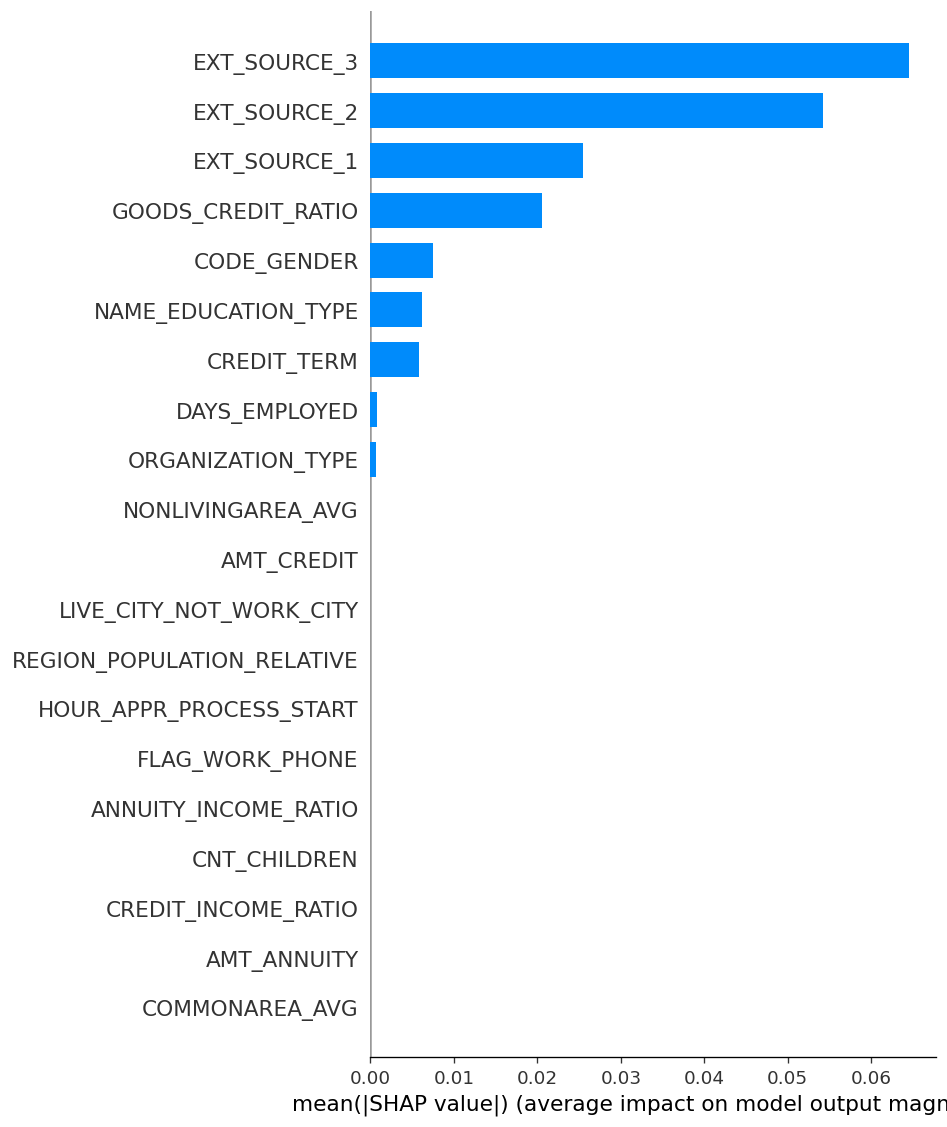

In [ ]:
# ── Bar Plot — Mean Absolute SHAP (Feature Importance) ───────────────────────
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test_sample,
    plot_type='bar',
    max_display=20,
    show=True
)

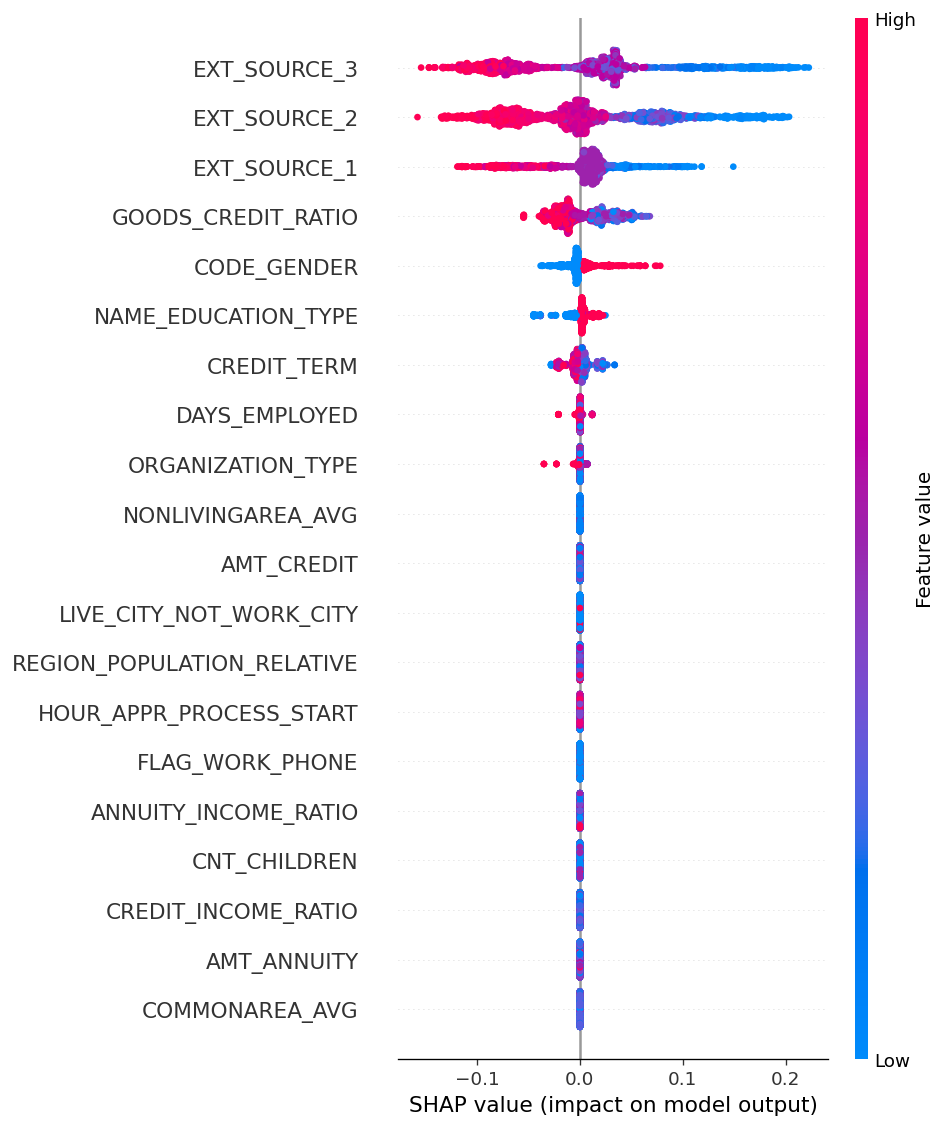

In [ ]:
# ── Dot/Beeswarm Plot — Direction and Magnitude of Impact ─────────────────────
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test_sample,
    max_display=20,
    show=True
)

### 8.2 — SHAP Dependence Plots (Top 3 Features)

Top 3 features: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1']


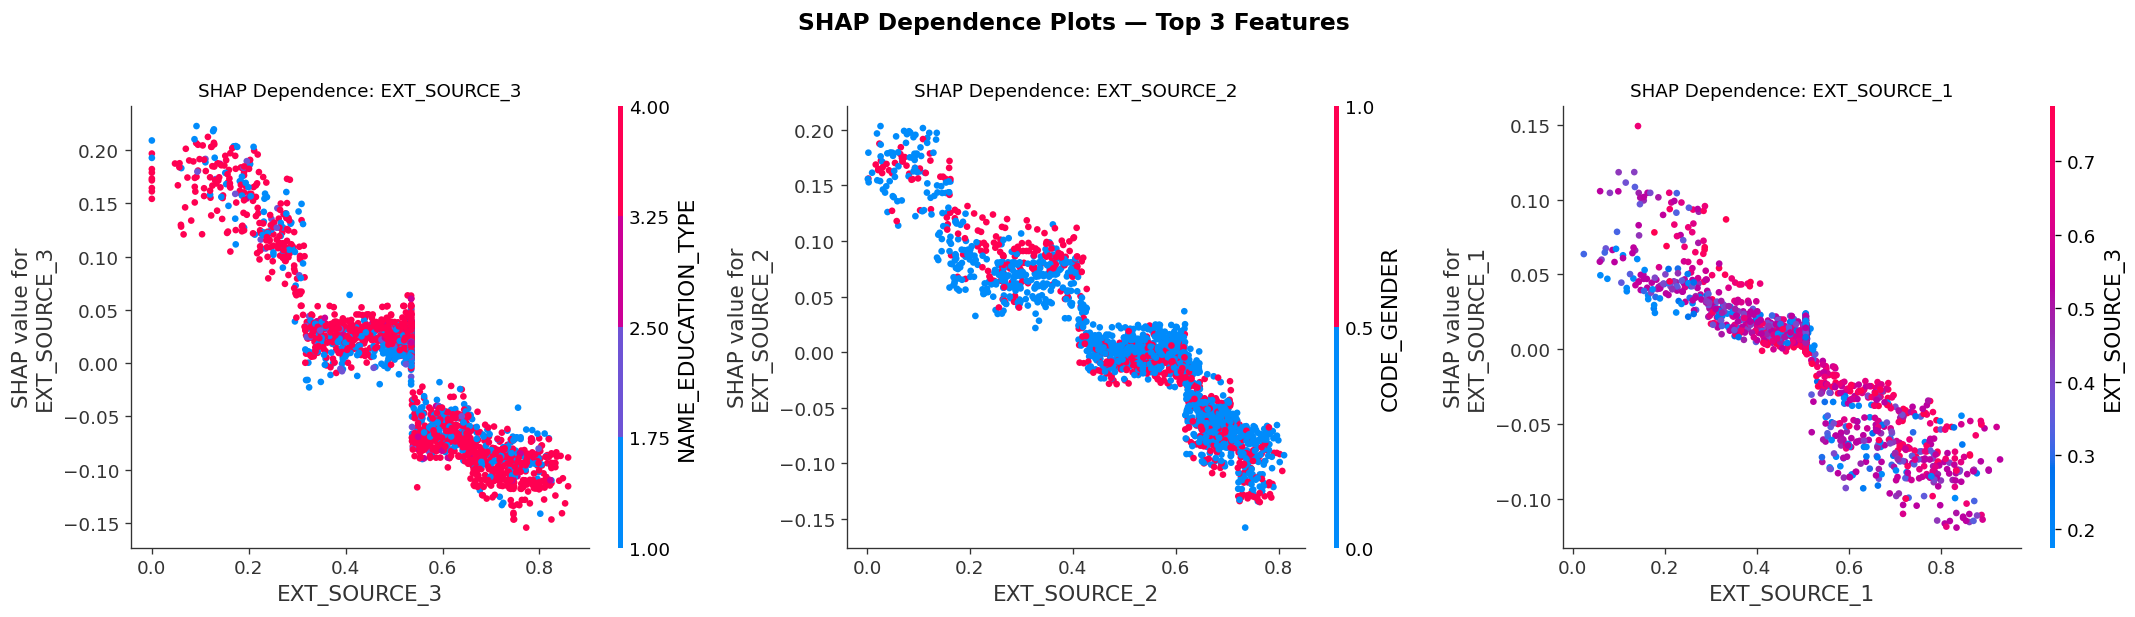

In [ ]:
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── Top 3 features by mean |SHAP| ─────────────────────────────────────────────
mean_shap = np.abs(sv).mean(axis=0)
top3_idx  = np.argsort(mean_shap)[::-1][:3]
top3_feats = X_test_sample.columns[top3_idx].tolist()

print(f"Top 3 features: {top3_feats}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_feats):
    shap.dependence_plot(
        feat, sv, X_test_sample,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.3 — Local Explanation (Individual Applicant)

In [ ]:
# ── Explain a predicted DEFAULTER ─────────────────────────────────────────────
y_pred_sample = lgbm.predict(X_test_sample)
default_idx   = np.where(y_pred_sample == 1)[0]

if len(default_idx) > 0:
    idx = default_idx[0]
    print(f"Explaining applicant at sample index {idx} (predicted: DEFAULT)")
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list)
            else explainer.expected_value,
        sv[idx],
        X_test_sample.iloc[idx],
        matplotlib=True
    )
else:
    print("No defaulters found in sample — adjust threshold or sample size.")

No defaulters found in sample — adjust threshold or sample size.


Explaining applicant at sample index 0 (predicted: NO DEFAULT)


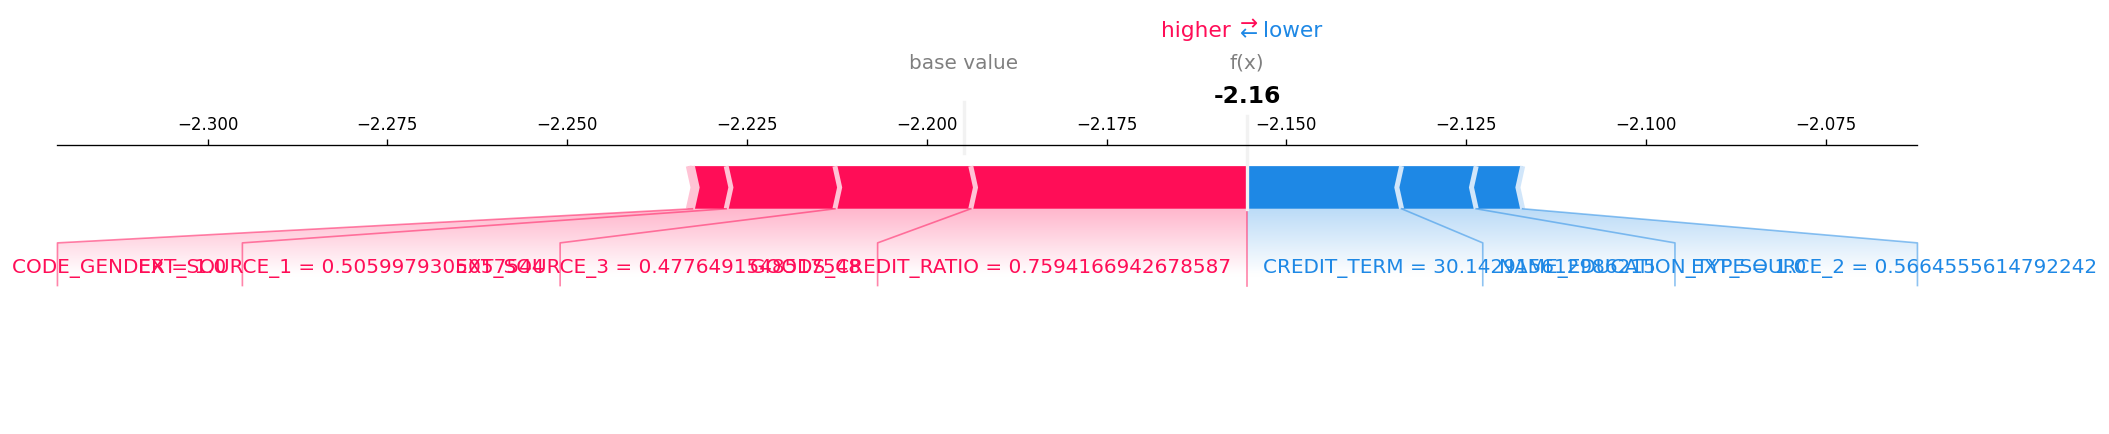

In [ ]:
# ── Explain a predicted NON-DEFAULTER ────────────────────────────────────────
safe_idx = np.where(y_pred_sample == 0)[0]

if len(safe_idx) > 0:
    idx = safe_idx[0]
    print(f"Explaining applicant at sample index {idx} (predicted: NO DEFAULT)")
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list)
            else explainer.expected_value,
        sv[idx],
        X_test_sample.iloc[idx],
        matplotlib=True
    )

### 8.4 — SHAP Waterfall Plot (Applicant-Level)

In [ ]:
# ── Waterfall for first defaulter ─────────────────────────────────────────────
if len(default_idx) > 0:
    idx = default_idx[0]
    exp = shap.Explanation(
        values         = sv[idx],
        base_values    = explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                            else explainer.expected_value,
        data           = X_test_sample.iloc[idx].values,
        feature_names  = X_test_sample.columns.tolist()
    )
    shap.waterfall_plot(exp, max_display=15)
    plt.title('SHAP Waterfall — Predicted Defaulter', fontweight='bold')
    plt.tight_layout()
    plt.show()

### 8.5 — SHAP for Random Forest (comparison)

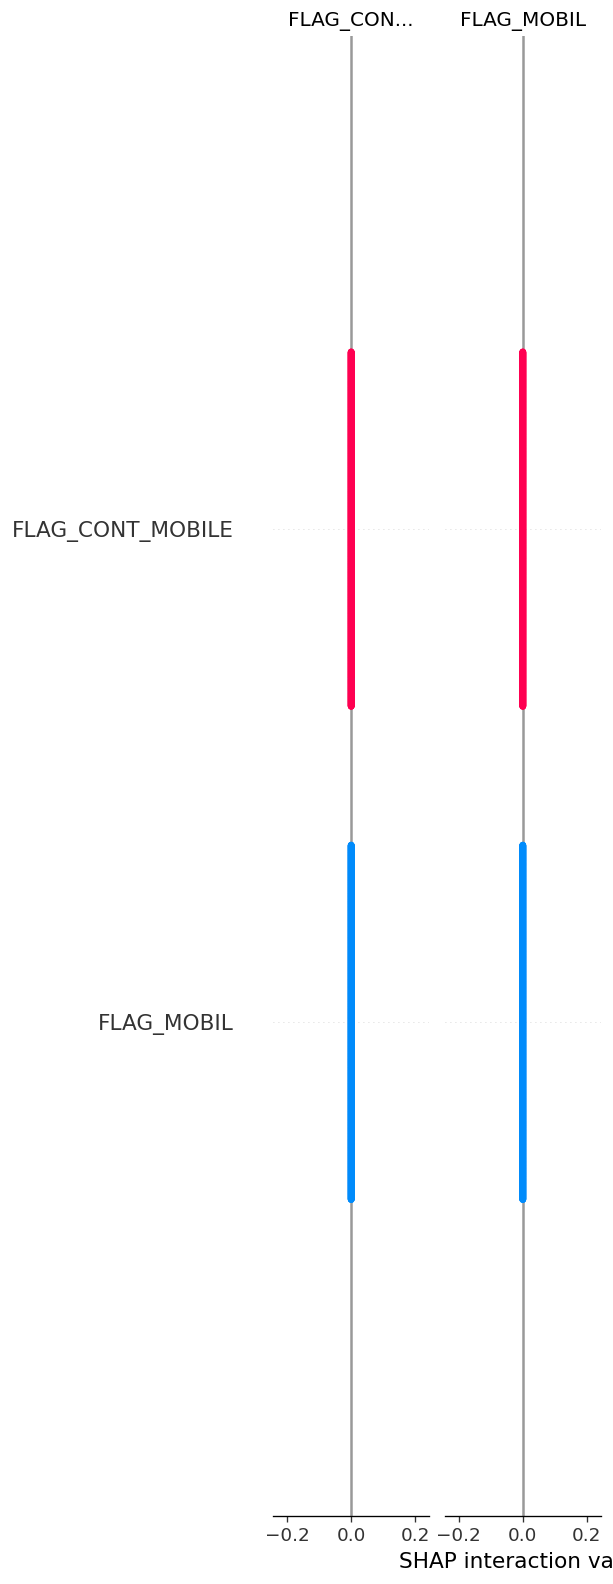

Text(0.5, 1.0, 'Random Forest — SHAP Feature Importance')

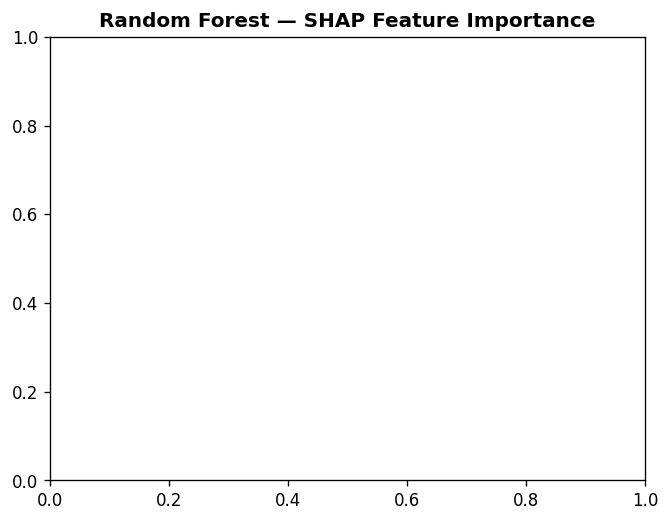

In [ ]:
explainer_rf   = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

sv_rf = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf

shap.summary_plot(
    sv_rf,
    X_test_sample,
    plot_type='bar',
    max_display=15,
    show=True
)
plt.title('Random Forest — SHAP Feature Importance', fontweight='bold')

---
## SAVE MODELS (for Streamlit Deployment — Stage 9)

In [ ]:
import joblib
import json
from google.colab import files

# Save models temporarily in Colab
joblib.dump(lgbm, "lgbm_model.pkl")
joblib.dump(rf, "rf_model.pkl")
joblib.dump(lr, "lr_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(top_feats, "top_features.pkl")

# Save threshold
threshold_info = {'threshold': float(THRESHOLD)}

with open("threshold.json", "w") as f:
    json.dump(threshold_info, f)

print("All models and artefacts saved ✓")

# Automatically download files to PC
files.download("lgbm_model.pkl")
files.download("rf_model.pkl")
files.download("lr_model.pkl")
files.download("scaler.pkl")
files.download("top_features.pkl")
files.download("threshold.json")

All models and artefacts saved ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## SUMMARY — Stages 5–8

| Stage | What was done |
|-------|---------------|
| **5. Feature Engineering** | 8 domain-specific financial ratios engineered; high-correlation features dropped; top 50 features selected by mutual information |
| **6. Model Training** | Logistic Regression (class-weighted), Random Forest (class-weighted), LightGBM (scale_pos_weight) — all trained on SMOTE-balanced data |
| **7. Evaluation** | Confusion matrices, ROC-AUC curves, Precision-Recall curves, summary table, 5-fold CV, threshold tuning for optimal Recall |
| **8. Explainability** | SHAP TreeExplainer — global summary (bar + beeswarm), dependence plots, force plots for individuals, waterfall charts |

→ **Best model: LightGBM** — highest ROC-AUC and best Recall at optimised threshold.  
→ Models saved to `/models/` folder for Streamlit deployment (Stage 9).